In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

C:\Users\zaine\AppData\Local\Temp\ipykernel_10284\3060170301.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:
docs = (
    PyPDFLoader("./documents/DSwithBappy_Company_Policies.pdf").load()
    + PyPDFLoader("./documents/DSwithBappy_Company_Profile.pdf").load()
    + PyPDFLoader("./documents/DSwithBappy_Product_and_Pricing.pdf").load()
)

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [6]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]

    answer: str

In [8]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [9]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [10]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [11]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

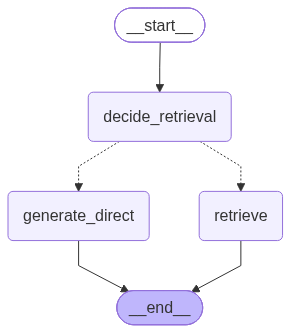

In [12]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", END)  # temporary END for retrieval path

app = g.compile()
app

In [13]:
result = app.invoke(
    {
        "question": "What is Pyramid",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

A pyramid is a three-dimensional geometric shape that has a polygonal base and triangular faces that converge at a single point called the apex. The most common type of pyramid is the square pyramid, which has a square base and four triangular faces. Pyramids are often associated with ancient civilizations, particularly in Egypt, where they were built as monumental tombs for pharaohs. The Great Pyramid of Giza is one of the most famous examples. In a broader context, the term "pyramid" can also refer to hierarchical structures in various fields, such as business, social organization, or information systems, where elements are arranged in levels of importance or authority.


In [14]:
result['need_retrieval']

False

In [15]:
result['docs']

[]

In [16]:
result = app.invoke(
    {
        "question": "Who is CEO of DSWithBappy",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

In [17]:
result['need_retrieval']

True

In [18]:
result['docs']

[Document(id='54fc213e-16dd-4d18-bde4-9ede45c42a79', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-26T04:40:11+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-26T04:40:11+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': './documents/DSwithBappy_Company_Profile.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='Founder\nBappy founded DSwithBappy with the goal of making modern AI engineering easier to\nunderstand through practical, step-by-step learning.\nThrough technical tutorials, courses, end-to-end projects, and community content, DSwithBappy\nfocuses on helping learners turn AI concepts into working applications.\nPlatform & Learning Team\nDSwithBappy brings together content creation, AI engineering, course development, project\nbuilding, and learner support to create a practical learning experience.\n●\n AI Engineering & Project Deve